# Brownian Motion

This notebook explores the properties of standard Brownian motion, including:
- Simulation of paths
- Self-similarity
- Distributional properties
- Various concepts regarding Brownian theory, such as nondifferentiability and unbounded variation

Note: This notebook generally follows section 1.3.1 of the text *Elementary Stochastic Calculus with Finance in View* by Thomas Mikosch

**Simulation of Brownian Paths**

In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [2]:
# Parameters #

# time
T=1.0
#increments
n=1000
dt=T/n

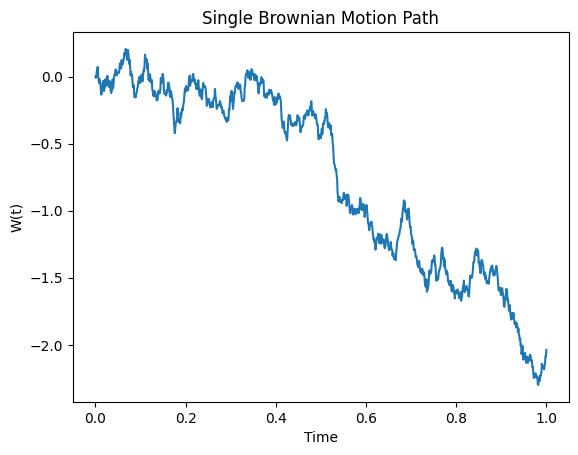

In [3]:
# simulate increments to form one Brownian Path

# By definition of Brownian motion, each RV B_t has a normal distribution.
Z=np.random.normal(0,1,n)

# Random movement over one time step. Scale our normal RVs by sqrt(dt) so that each dW ~ N(0,dt). Linear transformation
# Scale this way so that variance grows with time, since variance is additive for independent increments.
dW = np.sqrt(dt) * Z


# Construct Brownian path as sum of individual increments.
W=np.cumsum(dW)

# Sets initial condition B_0 as 0.
W = np.insert(W,0,0) 

# Create mesh
t=np.linspace (0, T, n+1)

# plot
plt.plot(t, W)
plt.title("Single Brownian Motion Path")
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.show()

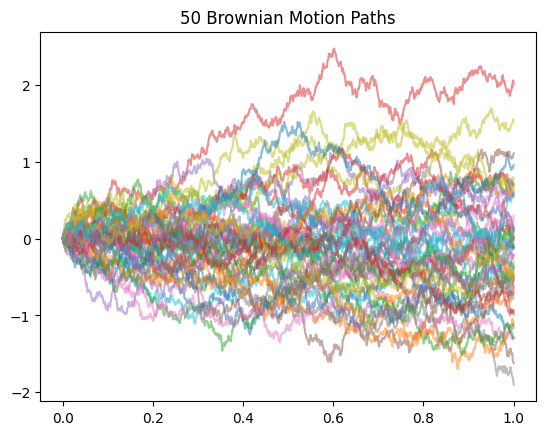

In [4]:
# Simulate many Brownian paths

for _ in range(50):
    Z = np.random.normal(0,1,n)
    W = np.insert(np.cumsum(np.sqrt(dt)*Z),0,0)
    plt.plot(t,W,alpha=0.5)

plt.title("50 Brownian Motion Paths")
plt.show()

**Distributional Properties of Brownian Motion: Verifying Theory Through Simulation**

Mean: 0.014734633931367213
Variance: 2.002136910365128


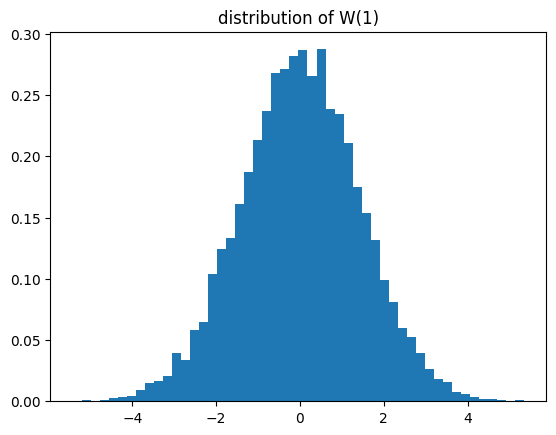

In [11]:
# Theory Verification
# In theory, a Brownian motion W ~ N(0,1)


final_values = []

for _ in range(10000):
    Z=np.random.normal(0,1,n)
    W=np.sum(np.sqrt(dt)*Z)
    final_values.append(W)


# Mean should be close to 0
print("Mean:", np.mean(final_values))
# Variance should be close to 1
print("Variance:", np.var(final_values))

# Distribution should be Gaussian (Normal). Check Histogram
plt.hist(final_values, bins=50, density=True)
plt.title("distribution of W(1)")
plt.show()

**Self-Similarity of Brownian Motion**


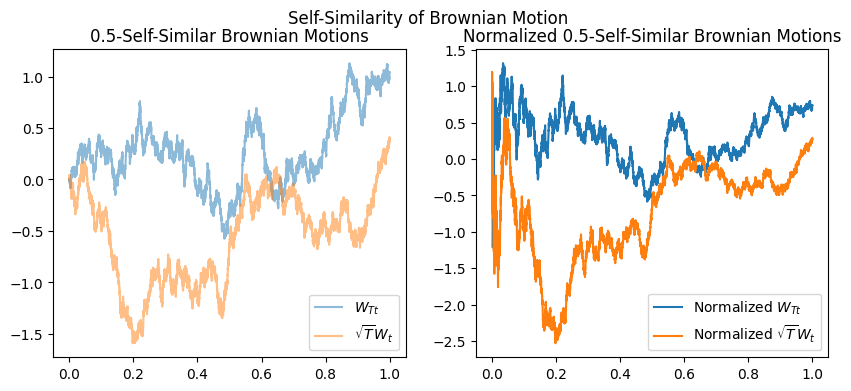

In [6]:
# Focusing on 0.5-self-similarity of Brownian motion


T=2
n=10000

dt=T/n
# Simulate one Brownian path
Z = np.random.normal(0,1,n)
W_full = np.insert(np.cumsum(np.sqrt(dt)*Z),0,0)

t_full =np.linspace(0,T,n+1)

# Extract W_{Tt}. Rescaling time. Speed up time so that our simulated path from [0,2] is now a path [0,1]

t = np.linspace(0,1,n+1)
indices = (t*n).astype(int)
W_Tt = W_full[indices]

# Simulate Brownian Motion of SQRT(T)*W_{t}. We are scaling a Brownian motion from [0,1] in space by SQRT(T)


dt_small = 1/n
Z2 = np.random.normal(0,1,n)
W =  np.insert(np.cumsum(np.sqrt(dt_small)*Z2),0,0)
scaled_W = np.sqrt(T)*W

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #
fig.suptitle("Self-Similarity of Brownian Motion") #
ax1.plot(t,W_Tt,alpha=0.5, label = '$W_{Tt}$')
ax1.plot(t,scaled_W,alpha=0.5, label ='$\\sqrt{T} W_{t}$')
ax1.legend()
ax1.set_title('0.5-Self-Similar Brownian Motions')

ax2.plot(t, W_Tt / np.sqrt(T*t + 1e-8), label='Normalized $W_{Tt}$')
ax2.plot(t, scaled_W / np.sqrt(T*t + 1e-8), label='Normalized $\\sqrt{T}W_t$')
ax2.legend()
ax2.set_title('Normalized 0.5-Self-Similar Brownian Motions')

plt.show()

Can't see much connection when looking at just one path. Self-similarity is NOT pathwise. These motions are equal in distribution, not necessarily in path. The second graph normalizes both motions, but still the similarity is not visually noticeable with individual motions.

What happens when we look at the distributions of 0.5-self-similar Brownian motions?

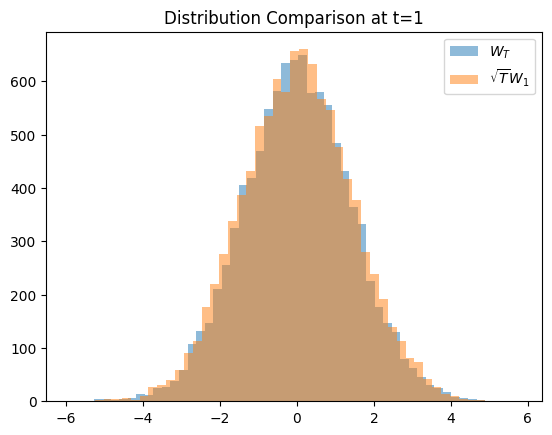

In [7]:
n_sim = 10000
W_T_vals = []
scaled_vals = []

for _ in range(n_sim):
    # 10000 simulations of W_{Tt}. Pull the endpoints of each motion into a vector.
    Z = np.random.normal(0,1,n)
    W_full = np.cumsum(np.sqrt(dt)*Z)
    W_T_vals.append(W_full[-1])  # W_T
    
    # 10000 simulations of # sqrt(T)W_t. Pull the endpoints of each motion into a vector.
    Z2 = np.random.normal(0,1,n)
    W = np.cumsum(np.sqrt(1/n)*Z2)
    scaled_vals.append(np.sqrt(T)*W[-1])  # sqrt(T)W_1


#Compare our two vectors. After 10,000 simulations, how are the endpoints of our two motions distributed?
plt.hist(W_T_vals, bins=50, alpha=0.5, label=r'$W_T$')
plt.hist(scaled_vals, bins=50, alpha=0.5, label=r'$\sqrt{T}W_1$')
plt.legend()
plt.title("Distribution Comparison at t=1")
plt.show()


The distributions are similar, almost identically overlapping.

Let's compare the distributions at another time t. Say, the midpoint t=0.5 (node 5001)

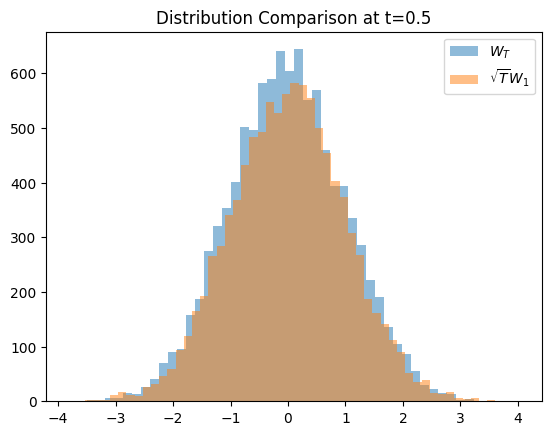

In [8]:
n_sim = 10000
W_T_vals = []
scaled_vals = []

for _ in range(n_sim):
    # 10000 simulations of W_{Tt}. Pull the endpoints of each motion into a vector.
    Z = np.random.normal(0,1,n)
    W_full = np.cumsum(np.sqrt(dt)*Z)
    W_T_vals.append(W_full[-5000])  # W_T
    
    # 10000 simulations of # sqrt(T)W_t. Pull the endpoints of each motion into a vector.
    Z2 = np.random.normal(0,1,n)
    W = np.cumsum(np.sqrt(1/n)*Z2)
    scaled_vals.append(np.sqrt(T)*W[-5000])  # sqrt(T)W_1


# Compare our two vectors. After 10,000 simulations, how are the endpoints of our two motions distributed?
plt.hist(W_T_vals, bins=50, alpha=0.5, label=r'$W_T$')
plt.hist(scaled_vals, bins=50, alpha=0.5, label=r'$\sqrt{T}W_1$')
plt.legend()
plt.title("Distribution Comparison at t=0.5")
plt.show()

Again, the distributions should be similar, almost identically overlapping. At any value of t, these distributions are equal. That is the definition of self-similarity.

Now we have seen that the distribution of these two motions are equal. What does self-similarity look like when applying to Brownian paths?

Let's simulate 50 paths of each motion.

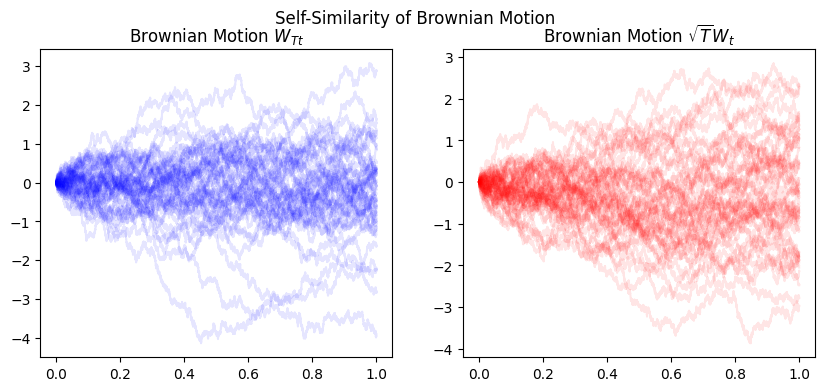

In [9]:
n_paths = 50
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #
fig.suptitle("Self-Similarity of Brownian Motion") #

for _ in range(n_paths):
    # W_{Tt}
    Z = np.random.normal(0,1,n)
    W_full = np.insert(np.cumsum(np.sqrt(dt)*Z),0,0)
    W_Tt = W_full[indices]
    
    ax1.plot(t, W_Tt, color='blue', alpha=0.1)
    ax1.set_title('Brownian Motion $W_{Tt}$')

for _ in range(n_paths):
    # sqrt(T) W_t
    Z2 = np.random.normal(0,1,n)
    W = np.insert(np.cumsum(np.sqrt(1/n)*Z2),0,0)
    scaled_W = np.sqrt(T)*W
    
    ax2.plot(t, scaled_W, color='red', alpha=0.1)
    ax2.set_title('Brownian Motion $\\sqrt{T}W_{t}$')
plt.show()

Recall that individual 0.5-Self-Similar Brownian motions did not look all that similar. In simulating a larger number of paths, we can now see the similarity of these motions.

**Other important aspects of theory of Brownian motion**




- Unbounded variation
    - For n increments in a Brownian path, we have the size of each increment defined as $\sim \sqrt{dt}$. 
    - We also know the relationship $n = \frac{1}{dt}$.
    - Our total variation is $ n \cdot \sqrt{dt}$, which can be simplified to $\frac{1}{\sqrt{dt}}$.
    - As we refine our partition further and further, $n \to \infty$, or equivalently, $dt \to 0$.  
    - Thus, our total variation $\frac{1}{\sqrt{dt}} \to \infty$<br>
<br>

- Nowhere differentiability: Brownian paths are continuous yet nowhere differentiable
    - Our derivative for a Brownian path would be $\lim_{h \to 0} \frac{B_{t+h} - B_{t}}{h}.$ 
    - Note that the numerator is defined as $\sim N(0,h)$, which means the typical variation (standard deviation) over $B_{t+h} - B_{t}$ is $\sqrt{h}$. 
    - Thus, our derivative simplifies $\frac{1}{\sqrt{h}}$, which does not converge as we take the $\lim_{h \to 0}$.

<br>

Both of these traits are driven by the fact that Brownian increments are scaled by $\sqrt{dt}.$
This causes an accumulation of infinite variation and makes local linear approximation impossible. <br> <br> 


**Simulation of unbounded variation**

n=100, Total Variation ≈ 11.324676452285054
n=500, Total Variation ≈ 26.622495608312732
n=1000, Total Variation ≈ 35.69107549851883
n=5000, Total Variation ≈ 79.99670654963276
n=10000, Total Variation ≈ 113.65675131262046


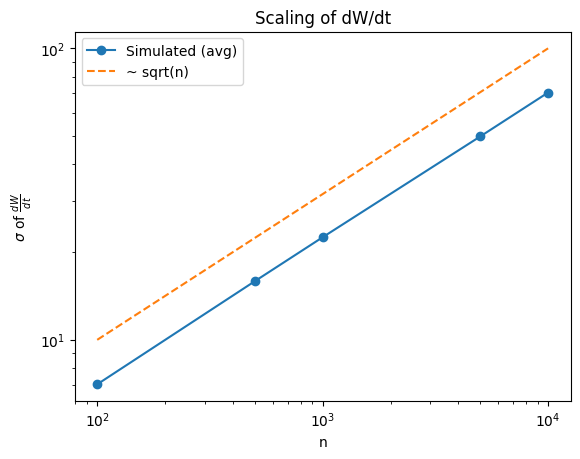

In [10]:

# Simulate unbounded variation
# As our mesh refines, variation diverges.
n_values = [100, 500, 1000, 5000, 10000]
n_sim = 50  # average over many runs

for n in n_values:
    dt = T / n
    Z = np.random.normal(0,1,n)
    dW = np.sqrt(dt) * Z
    
    total_variation = np.sum(np.abs(dW))
    print(f"n={n}, Total Variation ≈ {total_variation}")


# Simulate nowhere differentiability by simulating growth of standard deviation of dW/dt.
stds = []

for n in n_values:
    dt = T / n
    sim_stds = []

    # Simulate the growth of dW/dt from n=100 to n=10000. Repeat simulation to get mean growth of standard deviation of dW/dt.
    for _ in range(n_sim):
        Z = np.random.normal(0,1,n)
        dW = np.sqrt(dt) * Z
        ratios = dW / dt
        sim_stds.append(np.std(ratios))
    
    stds.append(np.mean(sim_stds))



# Compare to theoretical growth of dW/dt. In theory, the standard deviation of dW/dt grows like sqrt(n) (which is 1/sqrt(dt)).
theory = [np.sqrt(n) for n in n_values]

plt.plot(n_values, stds, marker='o', label='Simulated (avg)')
plt.plot(n_values, theory, linestyle='--', label='~ sqrt(n)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('n')
plt.ylabel('$\\sigma$ of $\\frac{dW}{dt}$')
plt.legend()
plt.title("Scaling of dW/dt")
plt.show()


We see that the simulation of difference quotients of Brownian motions roughly matches our theoretical expectation.
What does this mean? <br>
We see that $\sigma(\frac{dW}{dt}) \sim \sqrt{n}$ <br>
$\implies \sigma(\frac{dW}{dt}) \sim \frac{1}{\sqrt{dt}}.$ <br>
As $n \to \infty$, or equivalently $dt \to 0$, $\sigma(\frac{dW}{dt}) \to \infty.$ <br>
Convergence of this difference quotient to a finite value would require $\operatorname{var} (\frac{dW}{dt}) \to 0.$ But we see that variance/standard deviation diverges.
Thus, as we refine our mesh, the difference quotient does not stabilize/converge.
Hence, Brownian motion is nowhere differentiable.